# 1 - MNIST Double Digit Number Dataset Generation
Generating a double double digit number images dataset from MNIST original datasets.

## 01: Dependencies and Imports

In [1]:
%pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [2]:
import glob
import os
import random

import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
from torchvision import datasets, transforms

## 02: Original Data Load

In [3]:

# Download MNIST datasets.
mnist_train = datasets.MNIST(root='../data', train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST(root='../data', train=False, download=True, transform=transforms.ToTensor())

In [4]:
# 2. Define the path where the raw files are stored
raw_folder = '../data/MNIST/raw'

# 3. Find all files ending in .gz
gz_files = glob.glob(os.path.join(raw_folder, '*.gz'))

# 4. Delete them to reduce redundancy
if gz_files:
    print("\nRemoving redundant compressed files...")
    for file in gz_files:
        os.remove(file)
        print(f"Deleted: {file}")
    print("Cleanup complete! Only uncompressed files remain.")
else:
    print("\nNo .gz files found. Already cleaned up!")


No .gz files found. Already cleaned up!


## 03: Transform Data

In [5]:
class DoubleDigitMNIST(torch.utils.data.Dataset):
    def __init__(self, root_dir='../data', train=True, length=60000):
        self.original_mnist = datasets.MNIST(
            root=root_dir, 
            train=train, 
            download=False, 
            transform=transforms.ToTensor()
        )
        self.length = length
        
        # NUEVO: Pre-clasificamos los índices por dígito (0-9)
        self.indices_por_etiqueta = {i: [] for i in range(10)}
        for idx, (_, label) in enumerate(self.original_mnist):
            self.indices_por_etiqueta[label].append(idx)
        
    def __len__(self):
        return self.length
        
    def __getitem__(self, idx):
        # 1. Elegimos una etiqueta final estrictamente entre 0 y 27
        combined_label = random.randint(0, 27)
        
        # 2. Calculamos qué dígito necesitamos para las decenas y las unidades
        label1 = combined_label // 10  # Decenas (siempre será 0, 1 o 2)
        label2 = combined_label % 10   # Unidades
        
        # 3. Escogemos índices aleatorios de nuestras listas filtradas
        idx1 = random.choice(self.indices_por_etiqueta[label1])
        idx2 = random.choice(self.indices_por_etiqueta[label2])
        
        # 4. Extraemos las imágenes
        img1, _ = self.original_mnist[idx1]
        img2, _ = self.original_mnist[idx2]
        
        # 5. Concatenamos
        combined_img = torch.cat((img1, img2), dim=2)
        
        return combined_img, combined_label

print("Cargando dataset local...")
train_dataset_2digits = DoubleDigitMNIST(root_dir='../data', train=True, length=60000)
print(f"Total de imágenes listas: {len(train_dataset_2digits)}")

Cargando dataset local...
Total de imágenes listas: 60000


In [6]:
# 2. Instantiate the training dataset
print("Loading local dataset...")
train_dataset_2digits = DoubleDigitMNIST(root_dir='../data', train=True)
print(f"Total images ready: {len(train_dataset_2digits)}")

Loading local dataset...
Total images ready: 60000


In [7]:
os.makedirs('../data/MNIST_2DIGITS', exist_ok=True)

def generar_y_guardar_dataset(root_dir='../data', train=True, num_samples=60000):
    original_mnist = datasets.MNIST(
        root=root_dir, 
        train=train, 
        download=False, 
        transform=transforms.ToTensor()
    )
    
    # Pre-clasificamos los índices por dígito (0-9)
    indices_por_etiqueta = {i: [] for i in range(10)}
    for idx, (_, label) in enumerate(original_mnist):
        indices_por_etiqueta[label].append(idx)
        
    lista_imagenes = []
    lista_etiquetas = []
    
    tipo = "Training" if train else "Test"
    print(f"Generando {num_samples} muestras para el set de {tipo}...")
    
    for _ in range(num_samples):
        # 1. Elegimos la etiqueta objetivo (0 a 27)
        etiqueta_combinada = random.randint(0, 27)
        label1 = etiqueta_combinada // 10
        label2 = etiqueta_combinada % 10
        
        # 2. Buscamos imágenes específicas para esos dígitos
        idx1 = random.choice(indices_por_etiqueta[label1])
        idx2 = random.choice(indices_por_etiqueta[label2])
        
        img1, _ = original_mnist[idx1]
        img2, _ = original_mnist[idx2]
        
        # 3. Combinamos
        imagen_combinada = torch.cat((img1, img2), dim=2) 
        
        lista_imagenes.append(imagen_combinada)
        lista_etiquetas.append(etiqueta_combinada)
        
    tensor_imagenes = torch.stack(lista_imagenes)
    tensor_etiquetas = torch.tensor(lista_etiquetas)
    
    nombre_archivo = "train_2digits.pt" if train else "test_2digits.pt"
    ruta_guardado = f'../data/MNIST_2DIGITS/{nombre_archivo}'
    
    torch.save({'imagenes': tensor_imagenes, 'etiquetas': tensor_etiquetas}, ruta_guardado)
    print(f"Dataset guardado exitosamente en: {ruta_guardado}!\n")

In [8]:
# Ejecutamos las funciones
generar_y_guardar_dataset(train=True, num_samples=60000)
generar_y_guardar_dataset(train=False, num_samples=10000)

Generando 60000 muestras para el set de Training...
Dataset guardado exitosamente en: ../data/MNIST_2DIGITS/train_2digits.pt!

Generando 10000 muestras para el set de Test...
Dataset guardado exitosamente en: ../data/MNIST_2DIGITS/test_2digits.pt!



## 04: Show Data Results Examples

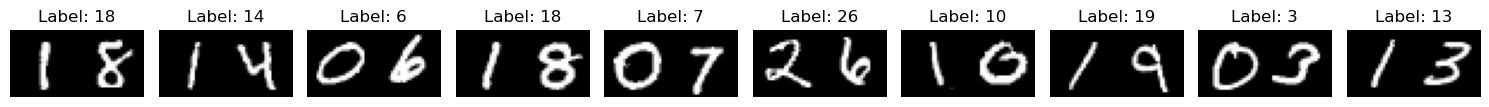

In [9]:
fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for i in range(10):
    idx = random.randint(0, len(train_dataset_2digits) - 1)
    img, label = train_dataset_2digits[idx]
    
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()